## Importación de librerías


In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# DuckDB, librería de lectura SQL optimizada, para agilizar la transformación de variables
import duckdb as ddb

# NuestrasFunciones, repertorio de fórmulas compartido por el profesor Guillermo Villarino en la asignatura Minería de datos y Modelización predictiva
from Formulas.NuestrasFunciones import histogram_boxplot, plot

In [2]:
Municipios = pd.read_csv('Datos procesados/MunicipiosGeo.csv', sep=';', encoding='UTF-8')
ProvinciasGeo = pd.read_csv('Datos procesados/ProvinciasGeo.csv', sep=';', encoding='UTF-8')
PuntosTuristicos = pd.read_csv('Datos procesados/PuntosTuristicos.csv', sep=';', encoding='UTF-8')
# Mapa de municipios. 
# Agradecimientos al profesor Lorenzo Escot por adjuntar este mapa dentro del temario de "Minería de datos y modelización predictiva"

Map_muni = gpd.read_file('cartografias/Munic04_ESP.shp')

En primer lugar, tendremos que definir bien el tipo de dato de nuestros datos, comenzaremos con una revisión del tipo de dato

In [3]:
Columnas = ['COD_PROV', 'cod_ine']
Map_muni[Columnas] = Map_muni[Columnas].astype('Int64')

In [4]:
Map_prov = Map_muni[['COD_PROV', 'PROV','CCAA', 'geometry']].dissolve(by='COD_PROV', as_index=False) #Comprimimos el mapa por provincia

Map_prov.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   COD_PROV  52 non-null     Int64   
 1   geometry  52 non-null     geometry
 2   PROV      52 non-null     str     
 3   CCAA      52 non-null     str     
dtypes: Int64(1), geometry(1), str(2)
memory usage: 1.8 KB


Comprobamos que `cod_ine` y `CODINE_MU` contienen los mismos valores. si la siguiente celda muestra como resultado 0, entonces todas serán idénticas

In [5]:
# Comprobamos
print( f'Número de valores diferentes en variables mencionadas: {Map_muni[Map_muni['cod_ine'] != Map_muni['CODINE_MU']].shape[0]}')

Número de valores diferentes en variables mencionadas: 8108


Al validar que son el mismo dato, la incluimos en la lista de variables que queremos eliminar para ahorrar memoria y simplificar

In [6]:
Map_muni = Map_muni.drop(columns= ['PROV','CCAA',
                                   'SP_ID','id',
                                   'POB_2016','POB_HO',
                                   'POB_MU','PARO_TO',
                                   'POB16_64','TASA_PARO',
                                   'RENTPCAP07', 'PrecioIn16']) # Eliminamos columnas que para este proyecto no son de interés
Map_muni.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 8108 entries, 0 to 8107
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   cod_ine    8108 non-null   Int64   
 1   CODINE_MU  8108 non-null   str     
 2   COD_PROV   8108 non-null   Int64   
 3   MUN        8108 non-null   str     
 4   geometry   8108 non-null   geometry
dtypes: Int64(2), geometry(1), str(2)
memory usage: 332.7 KB


In [7]:
ProvinciasGeo.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   COD_PROV                         52 non-null     int64  
 1   PROVINCIA                        52 non-null     str    
 2   COD_CA                           52 non-null     int64  
 3   COMUNIDAD_AUTONOMA               52 non-null     str    
 4   CAPITAL                          52 non-null     str    
 5   Perc_Provincia                   50 non-null     str    
 6   Perc_VALOR PERNOCTACIONES        50 non-null     float64
 7   Perc_VALOR VIAJERO               50 non-null     float64
 8   Perc_PERIODO PERNOCTACIONES      50 non-null     str    
 9   Perc_PERIODO VIAJERO             50 non-null     str    
 10  COD_INE                          52 non-null     int64  
 11  Ratios_Provincia                 52 non-null     str    
 12  Ratios_Periodo ADR Dato          52

In [8]:
# Creamos un dataframe con el codigo y nombre de cada CCAA

CCAA = ProvinciasGeo[['COD_CA', 'COMUNIDAD_AUTONOMA']].drop_duplicates().sort_values(by='COD_CA')
CCAA

,COD_CA,COMUNIDAD_AUTONOMA
3,1,Andalucía
21,2,Aragón
32,3,Principado de Asturias
6,4,Illes Balears
34,5,Canarias
38,6,Cantabria
4,7,Castilla y León
1,8,Castilla-La Mancha
7,9,Cataluña/Catalunya
2,10,Comunitat Valenciana


In [9]:
ProvinciasGeo = ProvinciasGeo.drop(columns=['COD_INE',
                                            'CAPITAL','Perc_Provincia',
                                            'Ratios_Provincia',
                                            'Metricas_provincia', 'cod_prov',
                                            'Metricas_n_meses','Metricas__meta.fecha_extraccion'])

ProvinciasGeo.head().T

,0,1,2,3,4
COD_PROV,1,2,3,4,5
PROVINCIA,Araba/Álava,Albacete,Alacant/Alicante,Almería,Ávila
COD_CA,16,8,10,1,7
COMUNIDAD_AUTONOMA,País Vasco/Euskadi,Castilla-La Mancha,Comunitat Valenciana,Andalucía,Castilla y León
Perc_VALOR PERNOCTACIONES,983700.0,796963.0,16463505.0,4563569.0,561006.0
Perc_VALOR VIAJERO,456184.0,370581.0,4346856.0,1364689.0,353460.0
Perc_PERIODO PERNOCTACIONES,M08,M09,M08,M08,M08
Perc_PERIODO VIAJERO,M08,M09,M08,M08,M08
Ratios_Periodo ADR Dato,M07,M09,M08,M08,M04
Ratios_Periodo ADR Tasa Var,M06,M11,M11,M09,M06


Comprobamos valores únicos en `Municipios` para comprobar qué columnas eliminar

In [10]:
Municipios.nunique()

COD_INE                     8132
COD_GEO                     8124
COD_PROV                      52
PROVINCIA                     52
NOMBRE_ACTUAL               8115
POBLACION_MUNI              3567
SUPERFICIE                  8128
PERIMETRO                   7599
COD_INE_CAPITAL             8132
CAPITAL                     8069
POBLACION_CAPITAL           3104
LONGITUD_ETRS89_REGCAN95    8132
LATITUD_ETRS89_REGCAN95     8131
ALTITUD                     1372
COD_CA                        19
COMUNIDAD_AUTONOMA            19
Personas_Valor              3572
Personas_Localidad          8115
Personas_Genero                1
Personas_Metrica               1
Personas_Unidad                1
dtype: int64

Eliminamos columnas no necesarias. Se incluye Longitud y Latitud ya que en los GeoDataFrames revisados anteriormente ya tenemos una columna `geometry` para municipios y provincias

In [11]:
# Drop de columnas que no necesitamos, para ahorrar recursos
# Como ya tenemos en  
Municipios = Municipios.drop(columns=['COD_GEO',
                                            'COD_INE_CAPITAL', 'CAPITAL',
                                            'Personas_Localidad', 'Personas_Genero',
                                            'Personas_Metrica', 'Personas_Unidad',
                                            'LONGITUD_ETRS89_REGCAN95', 'LATITUD_ETRS89_REGCAN95'])

print(Municipios.info())


<class 'pandas.DataFrame'>
RangeIndex: 8132 entries, 0 to 8131
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   COD_INE             8132 non-null   int64  
 1   COD_PROV            8132 non-null   int64  
 2   PROVINCIA           8132 non-null   str    
 3   NOMBRE_ACTUAL       8132 non-null   str    
 4   POBLACION_MUNI      8132 non-null   int64  
 5   SUPERFICIE          8132 non-null   str    
 6   PERIMETRO           8132 non-null   int64  
 7   POBLACION_CAPITAL   8132 non-null   int64  
 8   ALTITUD             8132 non-null   str    
 9   COD_CA              8132 non-null   int64  
 10  COMUNIDAD_AUTONOMA  8132 non-null   str    
 11  Personas_Valor      8132 non-null   float64
dtypes: float64(1), int64(6), str(5)
memory usage: 762.5 KB
None


In [12]:
def cambiar_tipodato(df, colnumeric,colfloat,colcat):
    # Cambiar coma decimal por punto
    for col in colfloat:
        df[col] = (
            df[col]
            .astype("string")
            .str.strip()
            .str.replace(",", ".", regex=False)
        )
        df[col] = pd.to_numeric(df[col], errors="raise")

    df = df.astype({
        **{col: "Int64" for col in colnumeric},
        **{col: "category" for col in colcat},
    })
    return df

In [13]:
colnumeric= ['COD_INE', 'POBLACION_MUNI', 
             'PERIMETRO', 'POBLACION_CAPITAL', 
             'Personas_Valor']
colfloat= ['SUPERFICIE', 'ALTITUD']
colcat = ['COD_PROV', 'COMUNIDAD_AUTONOMA', 'PROVINCIA']

Municipios = cambiar_tipodato(Municipios, colnumeric,colfloat,colcat)

Municipios.info()

<class 'pandas.DataFrame'>
RangeIndex: 8132 entries, 0 to 8131
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   COD_INE             8132 non-null   Int64   
 1   COD_PROV            8132 non-null   category
 2   PROVINCIA           8132 non-null   category
 3   NOMBRE_ACTUAL       8132 non-null   str     
 4   POBLACION_MUNI      8132 non-null   Int64   
 5   SUPERFICIE          8132 non-null   Float64 
 6   PERIMETRO           8132 non-null   Int64   
 7   POBLACION_CAPITAL   8132 non-null   Int64   
 8   ALTITUD             8132 non-null   Float64 
 9   COD_CA              8132 non-null   int64   
 10  COMUNIDAD_AUTONOMA  8132 non-null   category
 11  Personas_Valor      8132 non-null   Int64   
dtypes: Float64(2), Int64(5), category(3), int64(1), str(1)
memory usage: 652.3 KB


## Feature engineering

In [14]:
Municipios = Municipios.assign(
    densidad = Municipios['POBLACION_MUNI'] / Municipios['SUPERFICIE'],
    indice_perimetral = Municipios['PERIMETRO'] / Municipios['SUPERFICIE']
)

In [15]:
MunicipiosGeo = Map_muni.merge(Municipios,
                               right_on= 'COD_INE',
                               left_on='cod_ine',
                                )

MunicipiosGeo.head(2).T

,0,1
cod_ine,1001,1002
CODINE_MU,01001,01002
COD_PROV_x,1,1
MUN,Alegría-Dulantzi,Amurrio
geometry,MULTIPOLYGON (((-2.5306274999999996 42.8043295...,MULTIPOLYGON (((-3.0375913999999997 42.9801479...
COD_INE,1001,1002
COD_PROV_y,1,1
PROVINCIA,Araba/Álava,Araba/Álava
NOMBRE_ACTUAL,Alegría-Dulantzi,Amurrio
POBLACION_MUNI,2961,10346


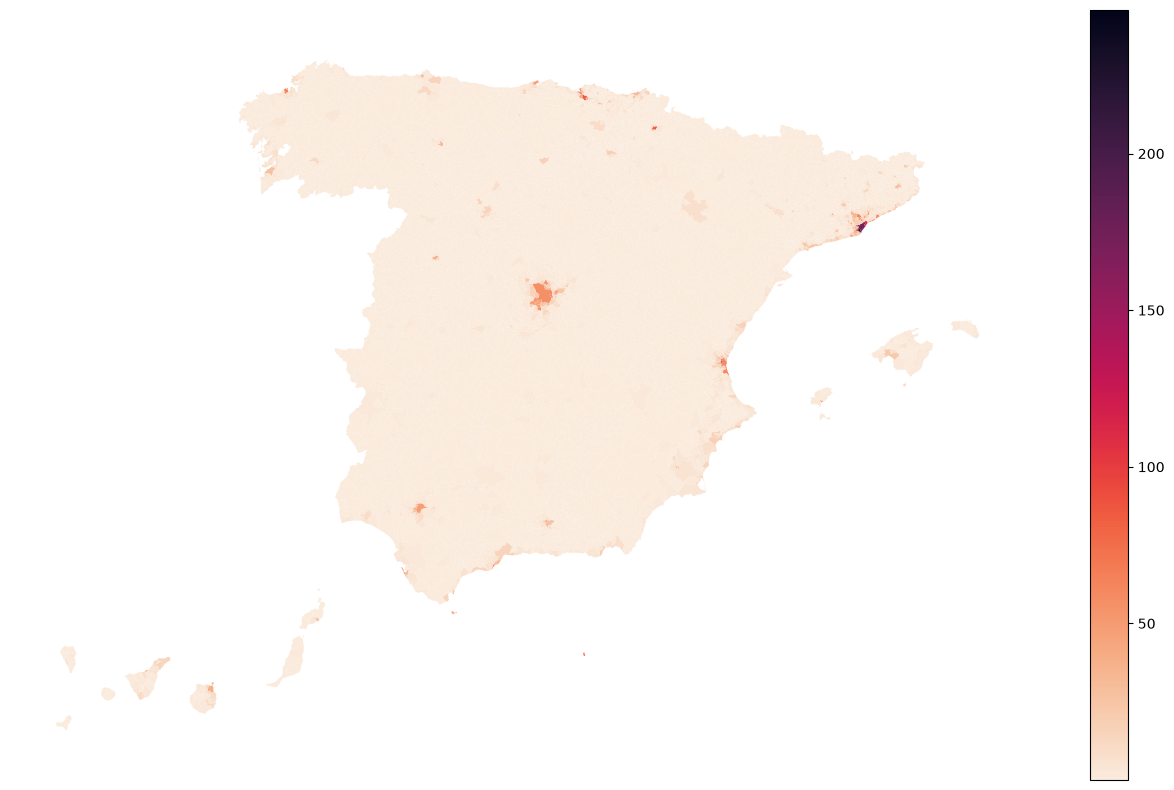

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(13, 8))

MunicipiosGeo.plot(
    column='densidad',
    cmap=sns.color_palette("rocket_r", as_cmap=True),
    legend=True,
    linewidth=0.6,
    ax=ax,
)

ax.axis('off')
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

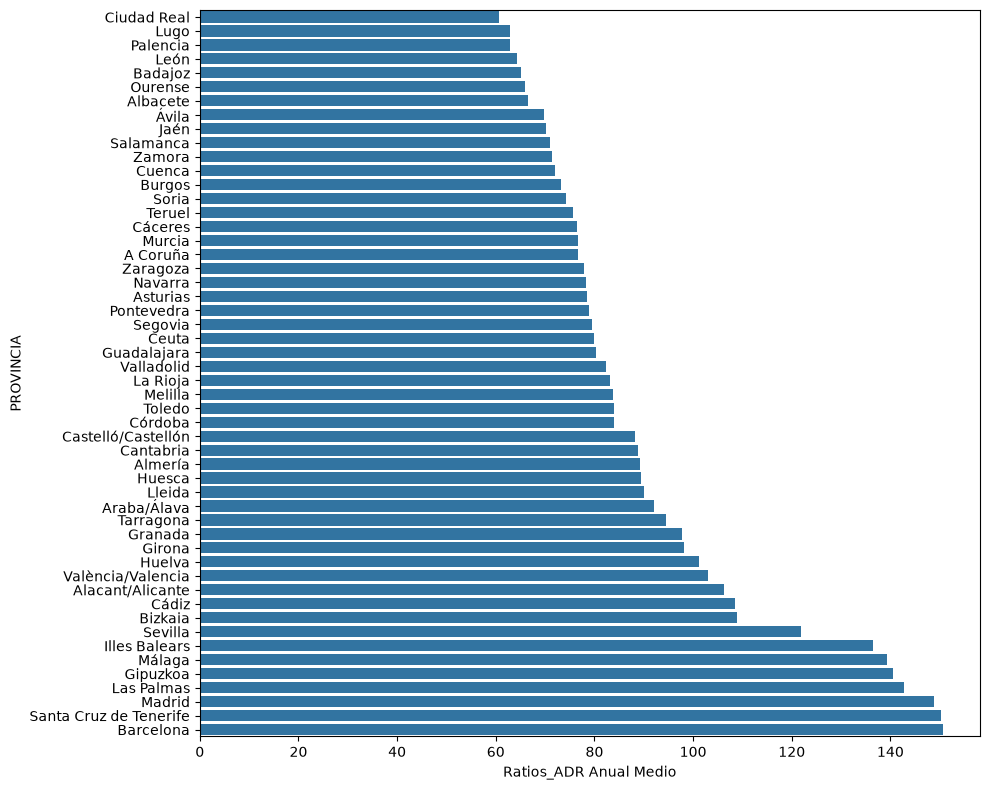

In [17]:
plt.figure(figsize=(10, 8))
sns.barplot(data=ProvinciasGeo.sort_values(by='Ratios_ADR Anual Medio'), y='PROVINCIA', x='Ratios_ADR Anual Medio' )
plt.tight_layout()
plt.show()

In [22]:
# Crear un gráfico de barras interactivo
fig = px.bar(
    ProvinciasGeo, 
    y='COMUNIDAD_AUTONOMA', 
    x='Perc_VALOR VIAJERO',
    orientation='h',
    title='Valores de Viajeros por Comunidad Autónoma',
    hover_data=['Metricas_indice_estacionalidad'], # Opcional: añade más datos para ver al pasar el cursor
)

# Mostrar el gráfico interactivo
fig.show()

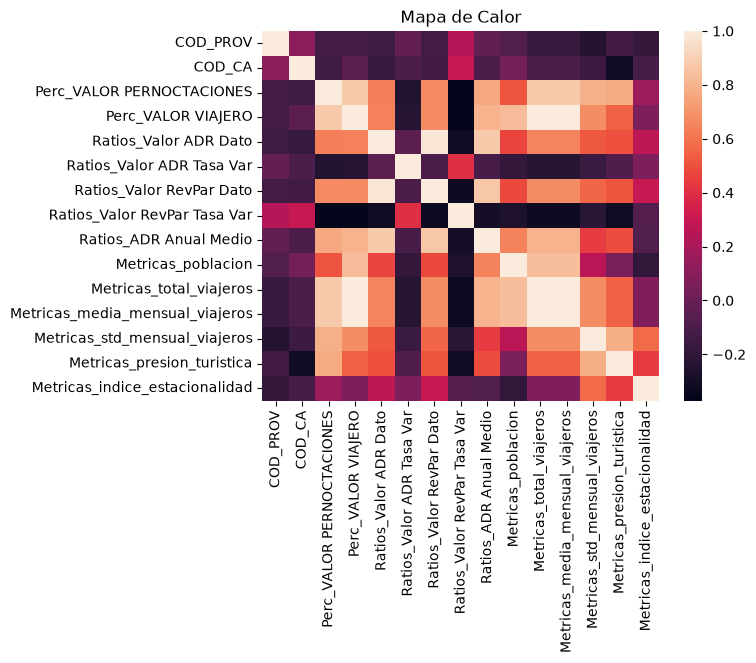

In [19]:
sns.heatmap(ProvinciasGeo.select_dtypes(include='number').corr(),
            )
plt.title('Mapa de Calor')
plt.show()

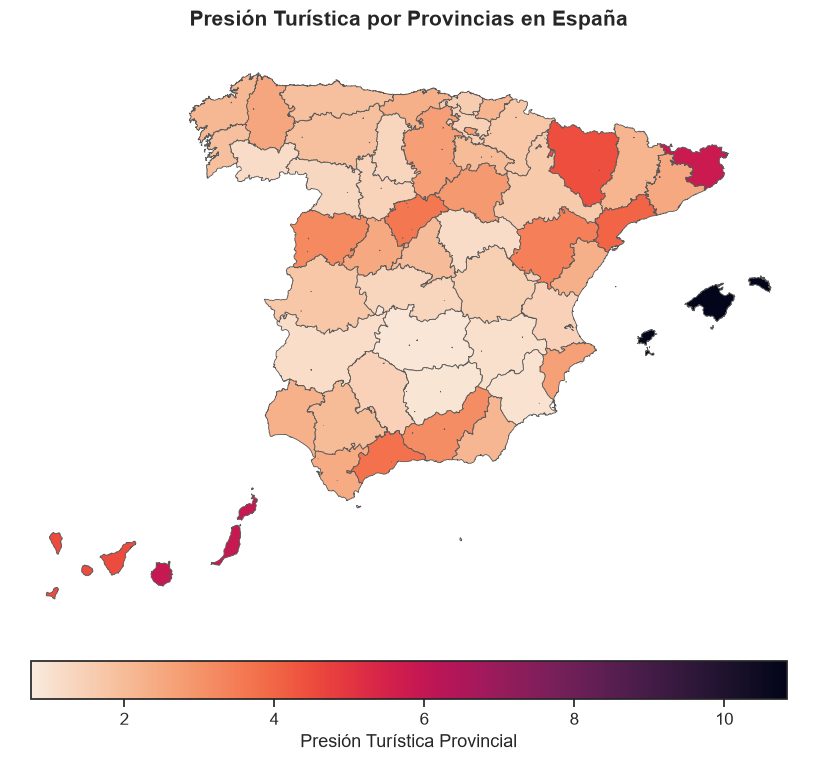

In [20]:
import geopandas as gpd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configurar la estética general con Seaborn
sns.set_theme(style="white", font_scale=1.1)

# 2. Cargar cartografía y preparar las 52 provincias
gdf_muni = gpd.read_file('cartografias/Munic04_ESP.shp')
gdf_muni['COD_PROV_INT'] = gdf_muni['COD_PROV'].astype(int)
gdf_provincias = gdf_muni.dissolve(by='COD_PROV_INT', as_index=False)

# 3. Unir con las métricas provinciales
gdf_prov_analisis = gdf_provincias.merge(
    ProvinciasGeo, 
    left_on='COD_PROV_INT', 
    right_on='COD_PROV', 
    how='inner'
)

# 4. Crear mapa de color continuo nativo de Seaborn (ej: 'rocket_r', 'flare' o 'mako_r')
cmap_seaborn = sns.color_palette("rocket_r", as_cmap=True)

# 5. Representación gráfica
fig, ax = plt.subplots(1, 1, figsize=(13, 8))

# Pintamos el mapa coroplético con el colormap de Seaborn
gdf_prov_analisis.plot(
    column='Metricas_presion_turistica',
    cmap=cmap_seaborn,
    legend=True,
    edgecolor='0.35',
    linewidth=0.6,
    ax=ax,
    legend_kwds={
        'label': "Presión Turística Provincial",
        'orientation': "horizontal",
        'shrink': 0.6,
        'pad': 0.05
    }
)

# Título y ajustes con estilo Seaborn
ax.set_title("Presión Turística por Provincias en España", fontsize=15, weight='bold', pad=15)
ax.axis('off')
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()